In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def convolution(image, filter_matrix, stride=1):
    rows, cols = image.shape
    f_rows, f_cols = filter_matrix.shape
    
    out_rows = (rows - f_rows) // stride + 1
    out_cols = (cols - f_cols) // stride + 1
    
    output = np.zeros((out_rows, out_cols))
    
    for i in range(out_rows):
        for j in range(out_cols):
            region = image[i*stride : i*stride + f_rows, j*stride : j*stride + f_cols]
            output[i, j] = np.sum(region * filter_matrix)
            
    return output

def relu(image):
    return np.maximum(0, image)

def max_pooling(image, pool_size=2):
    rows, cols = image.shape
    out_rows = rows // pool_size
    out_cols = cols // pool_size
    
    output = np.zeros((out_rows, out_cols))
    
    for i in range(out_rows):
        for j in range(out_cols):
            region = image[i*pool_size : (i+1)*pool_size, j*pool_size : (j+1)*pool_size]
            output[i, j] = np.max(region)
            
    return output

# CNN on Image

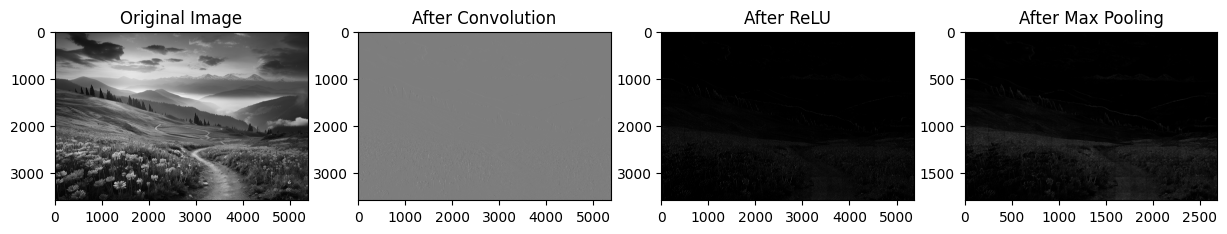

In [2]:
img = cv2.imread("../DL Practicals/scenary.jpg", cv2.IMREAD_GRAYSCALE)

sobel_filter = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])

conv_img = convolution(img, sobel_filter, stride=1)
relu_img = relu(conv_img)
pool_img = max_pooling(relu_img, pool_size=2)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1), plt.imshow(img, cmap='gray'), plt.title("Original Image")
plt.subplot(1, 4, 2), plt.imshow(conv_img, cmap='gray'), plt.title("After Convolution")
plt.subplot(1, 4, 3), plt.imshow(relu_img, cmap='gray'), plt.title("After ReLU")
plt.subplot(1, 4, 4), plt.imshow(pool_img, cmap='gray'), plt.title("After Max Pooling")
plt.show()

# CNN on Matrix

In [3]:
matrix = np.array([[3, 8, 1, 0, 5],
                   [2, 7, 4, 9, 2],
                   [8, 5, 3, 1, 6],
                   [0, 2, 7, 4, 8],
                   [5, 1, 6, 2, 9]])

simple_filter = np.array([[1, 0],
                          [0, -1]])

print("Original Matrix:\n", matrix)

conv_matrix = convolution(matrix, simple_filter, stride=1)
print("\nAfter Convolution:\n", conv_matrix)

relu_matrix = relu(conv_matrix)
print("\nAfter ReLU:\n", relu_matrix)

pool_matrix = max_pooling(relu_matrix, pool_size=2)
print("\nAfter Max Pooling:\n", pool_matrix)

Original Matrix:
 [[3 8 1 0 5]
 [2 7 4 9 2]
 [8 5 3 1 6]
 [0 2 7 4 8]
 [5 1 6 2 9]]

After Convolution:
 [[-4.  4. -8. -2.]
 [-3.  4.  3.  3.]
 [ 6. -2. -1. -7.]
 [-1. -4.  5. -5.]]

After ReLU:
 [[0. 4. 0. 0.]
 [0. 4. 3. 3.]
 [6. 0. 0. 0.]
 [0. 0. 5. 0.]]

After Max Pooling:
 [[4. 3.]
 [6. 5.]]


# CNN on Dataset

In [5]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

dataset_dir = "../Exp-4/shapes"

datagen = ImageDataGenerator(validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_dir, target_size=(64, 64), batch_size=8, class_mode='binary', subset='training'
)
val_gen = datagen.flow_from_directory(
    dataset_dir, target_size=(64, 64), batch_size=8, class_mode='binary', subset='validation'
)

model_dataset = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_dataset.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_dataset.fit(train_gen, validation_data=val_gen, epochs=3, verbose=1)


Found 78 images belonging to 2 classes.


Found 18 images belonging to 2 classes.
Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 146.6838 - val_accuracy: 0.5000 - val_loss: 98.0102
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5128 - loss: 25.1499 - val_accuracy: 0.5000 - val_loss: 5.8543
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6795 - loss: 5.6346 - val_accuracy: 0.6111 - val_loss: 7.2092
